# Healthcare ML — Stroke, Cardio & Brain Scan Prediction

In [1]:
# تأكد إنك على بيئة healthcare_ml قبل التشغيل
# Kernel > Change Kernel > Healthcare ML
import sys
print('Python:', sys.version)

import numpy as np
print('NumPy:', np.__version__)

import tensorflow as tf
print('TensorFlow:', tf.__version__)

import sklearn
print('Scikit-learn:', sklearn.__version__)

import xgboost
print('XGBoost:', xgboost.__version__)

print('All OK!')

Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
NumPy: 1.24.3
TensorFlow: 2.13.0
Scikit-learn: 1.3.2
XGBoost: 2.0.3
All OK!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import joblib

from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
os.makedirs('figures',      exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'figure.dpi':       120,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False
})

PALETTE = ['#2196F3', '#4CAF50', '#FF5722']
print('Libraries loaded OK.')

Libraries loaded OK.


## 1. Load Data from SQL Server

In [4]:
SERVER   = 'LAPTOP-0ET1RSM5'    # مثال: localhost  أو  DESKTOP-XXX\SQLEXPRESS
DATABASE = 'StrokePrediction'  # مثال: HealthcareDB

QUERY = """
    SELECT
        f.patient_id, f.age, f.hypertension, f.heart_disease,
        f.height, f.weight, f.ap_hi, f.ap_lo,
        f.cardio_cholesterol, f.cardio_gluc, f.avg_glucose_level,
        f.bmi, 
        f.avg_RestingBP, f.avg_Cholesterol, f.avg_MaxHR, f.avg_Oldpeak,
        f.heart_disease_rate,
        f.stroke, f.cardio,
        d.gender, d.ever_married, d.residence_type, d.work_type,
        l.smoking_status, l.smoke_flag, l.alco_flag
    FROM  gold.fact_patient_health  f
    LEFT JOIN gold.dim_patient_info d ON f.patient_id = d.patient_id
    LEFT JOIN gold.dim_lifestyle    l ON f.patient_id = l.patient_id
"""

conn_str = (
    f'mssql+pyodbc://{SERVER}/{DATABASE}'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

try:
    engine = create_engine(conn_str)
    df = pd.read_sql(QUERY, engine)
    print(f'Loaded: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
except Exception as e:
    print(f'Connection failed: {e}')
    print('Use CSV fallback below.')
    # df = pd.read_csv('fact_patient_health.csv')

Loaded: 5,110 rows  x  26 columns


## 2. Preprocessing

In [5]:
NUM_COLS = [
    'age', 'hypertension', 'heart_disease', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cardio_cholesterol', 'cardio_gluc',
    'avg_glucose_level', 'bmi', 'RestingBP', 'heart_cholesterol',
    'MaxHR', 'Oldpeak', 'smoke_flag', 'alco_flag'
]
CAT_COLS = ['gender', 'ever_married', 'residence_type', 'work_type', 'smoking_status']

df_enc = df.copy()
le = LabelEncoder()
for col in CAT_COLS:
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].fillna('Unknown')
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))

FEATURES = [c for c in NUM_COLS + CAT_COLS if c in df_enc.columns]
print(f'Features: {len(FEATURES)}')

def prepare(df, target):
    data  = df[FEATURES + [target]].dropna(subset=[target]).copy()
    X     = data[FEATURES].values.astype(np.float64)
    y     = data[target].astype(int).values

    imp   = SimpleImputer(strategy='median')
    X     = imp.fit_transform(X)

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    if y.mean() < 0.3:
        Xtr, ytr = SMOTE(random_state=42).fit_resample(Xtr, ytr)
        print(f'  [{target}] SMOTE applied — train size: {len(Xtr):,}')

    sc  = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)

    print(f'  [{target}] train={len(Xtr):,}  test={len(Xte):,}')
    return Xtr, Xte, ytr, yte, sc, imp

Xtr_s, Xte_s, ytr_s, yte_s, sc_s, imp_s = prepare(df_enc, 'stroke')
Xtr_c, Xte_c, ytr_c, yte_c, sc_c, imp_c = prepare(df_enc, 'cardio')
print('Preprocessing done.')

Features: 18
  [stroke] SMOTE applied — train size: 7,778
  [stroke] train=7,778  test=1,022
  [cardio] train=2,869  test=718
Preprocessing done.


## 3. Figure 1 — Data Pipeline

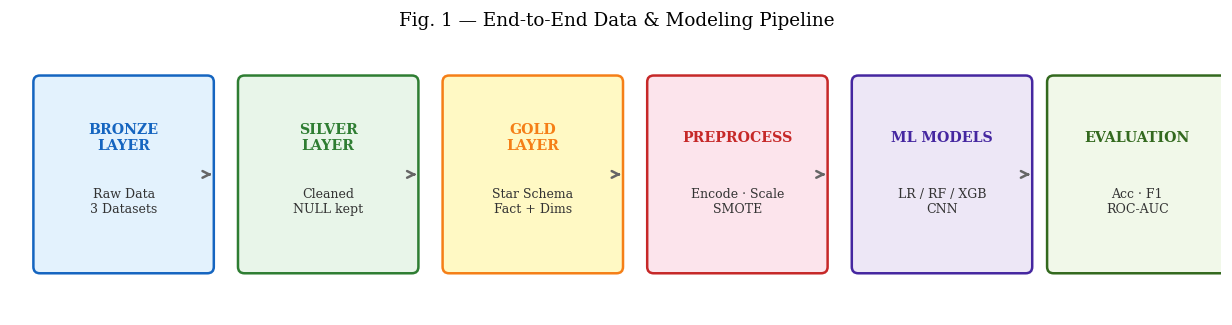

Saved: figures/fig1_pipeline.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    (0.3,  '#E3F2FD', '#1565C0', 'BRONZE\nLAYER',  'Raw Data\n3 Datasets'),
    (2.5,  '#E8F5E9', '#2E7D32', 'SILVER\nLAYER',  'Cleaned\nNULL kept'),
    (4.7,  '#FFF9C4', '#F57F17', 'GOLD\nLAYER',    'Star Schema\nFact + Dims'),
    (6.9,  '#FCE4EC', '#C62828', 'PREPROCESS',     'Encode · Scale\nSMOTE'),
    (9.1,  '#EDE7F6', '#4527A0', 'ML MODELS',      'LR / RF / XGB\nCNN'),
    (11.2, '#F1F8E9', '#33691E', 'EVALUATION',     'Acc · F1\nROC-AUC'),
]

for i, (x, fc, ec, title, sub) in enumerate(steps):
    box = mpatches.FancyBboxPatch(
        (x, 0.5), 1.8, 2.0,
        boxstyle='round,pad=0.07',
        facecolor=fc, edgecolor=ec, linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x + 0.9, 1.9, title, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=ec)
    ax.text(x + 0.9, 1.2, sub,   ha='center', va='center',
            fontsize=7.5, color='#333')
    if i < len(steps) - 1:
        ax.annotate(
            '', xy=(x + 1.85, 1.5), xytext=(x + 1.78, 1.5),
            arrowprops=dict(arrowstyle='->', color='#666', lw=1.5)
        )

ax.set_title('Fig. 1 — End-to-End Data & Modeling Pipeline', pad=6)
plt.savefig('figures/fig1_pipeline.png')
plt.show()
print('Saved: figures/fig1_pipeline.png')

## 4. Train Models

In [8]:
MODELS = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('XGBoost',             XGBClassifier(
                                n_estimators=100, random_state=42,
                                eval_metric='logloss',
                                use_label_encoder=False,
                                verbosity=0
                            )),
]

def run_models(Xtr, Xte, ytr, yte, task):
    results = []
    for name, clf in MODELS:
        clf.fit(Xtr, ytr)
        yp  = clf.predict(Xte)
        ypr = clf.predict_proba(Xte)[:, 1]
        r   = {
            'name': name, 'clf': clf,
            'yp':   yp,   'ypr': ypr,
            'acc':  accuracy_score(yte, yp),
            'f1':   f1_score(yte, yp, average='weighted'),
            'auc':  roc_auc_score(yte, ypr)
        }
        results.append(r)
        print(f'[{task}] {name:<22}  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}  AUC={r["auc"]:.3f}')
    return results

print('--- STROKE ---')
stroke_res = run_models(Xtr_s, Xte_s, ytr_s, yte_s, 'Stroke')
print()
print('--- CARDIO ---')
cardio_res = run_models(Xtr_c, Xte_c, ytr_c, yte_c, 'Cardio')

--- STROKE ---
[Stroke] Logistic Regression     Acc=0.760  F1=0.827  AUC=0.855
[Stroke] Random Forest           Acc=0.945  F1=0.926  AUC=0.810
[Stroke] XGBoost                 Acc=0.943  F1=0.928  AUC=0.795

--- CARDIO ---
[Cardio] Logistic Regression     Acc=0.749  F1=0.748  AUC=0.801
[Cardio] Random Forest           Acc=0.755  F1=0.754  AUC=0.794
[Cardio] XGBoost                 Acc=0.723  F1=0.722  AUC=0.768


## 5. Figure 2 — Model Comparison

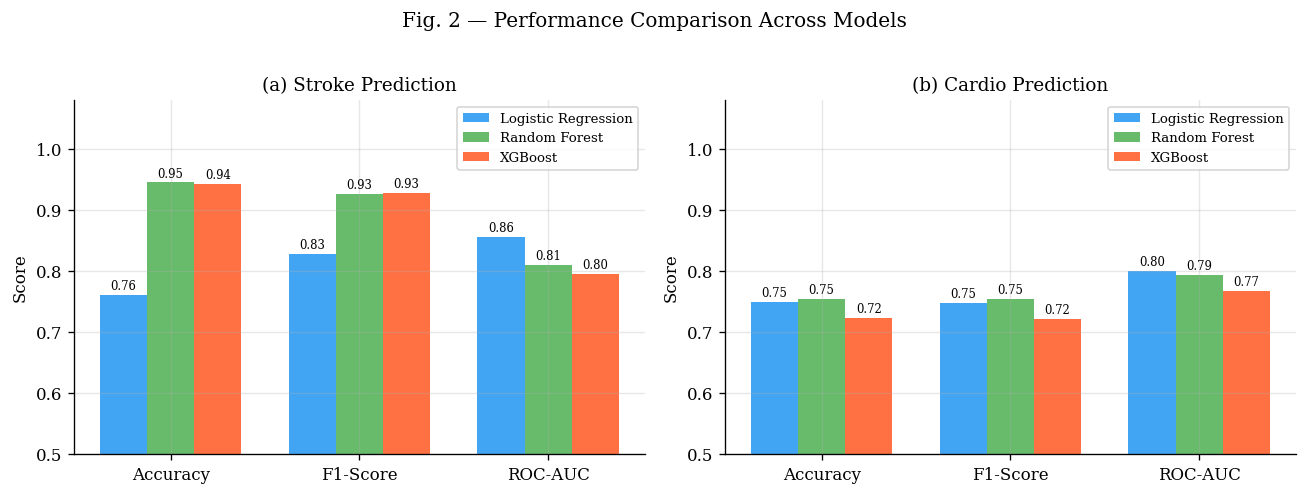

Saved: figures/fig2_model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(3)   # Accuracy, F1, AUC
w = 0.25
metric_labels = ['Accuracy', 'F1-Score', 'ROC-AUC']
metric_keys   = ['acc', 'f1', 'auc']

for ax, results, title in zip(
        axes,
        [stroke_res, cardio_res],
        ['(a) Stroke Prediction', '(b) Cardio Prediction']):

    for i, (r, col) in enumerate(zip(results, PALETTE)):
        vals = [r[k] for k in metric_keys]
        bars = ax.bar(x + i * w, vals, w, label=r['name'], color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7
            )

    ax.set_xticks(x + w)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0.5, 1.08)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Fig. 2 — Performance Comparison Across Models', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig2_model_comparison.png')
plt.show()
print('Saved: figures/fig2_model_comparison.png')

## 6. Figure 3 — ROC Curves

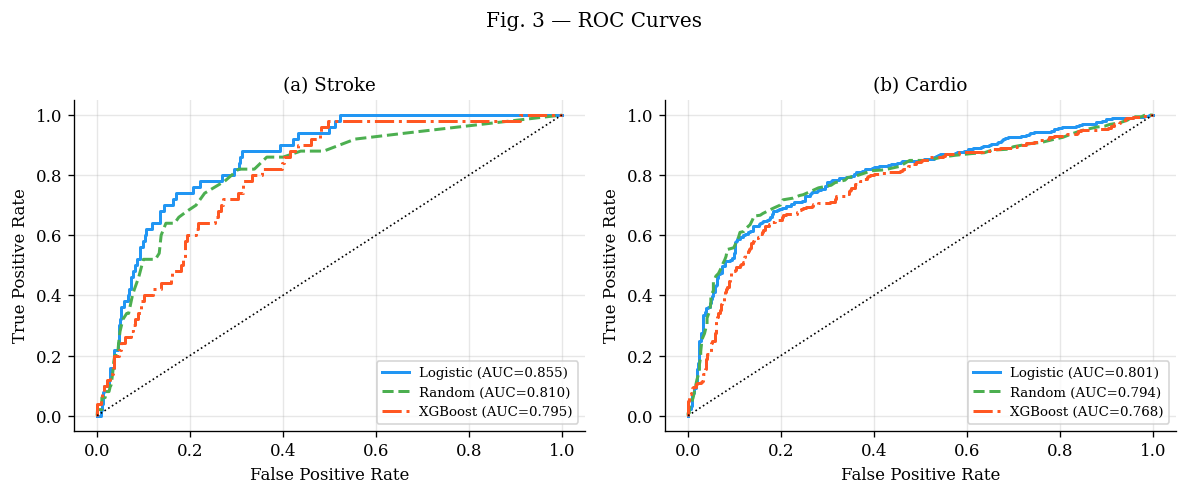

Saved: figures/fig3_roc_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ls_list   = ['-', '--', '-.']

for ax, results, yte, title in zip(
        axes,
        [stroke_res, cardio_res],
        [yte_s, yte_c],
        ['(a) Stroke', '(b) Cardio']):

    for r, ls, col in zip(results, ls_list, PALETTE):
        fpr, tpr, _ = roc_curve(yte, r['ypr'])
        short_name  = r['name'].split()[0]   # LR / Random / XGBoost
        ax.plot(fpr, tpr, ls=ls, color=col, lw=1.8,
                label=f"{short_name} (AUC={r['auc']:.3f})")

    ax.plot([0, 1], [0, 1], 'k:', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Fig. 3 — ROC Curves', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig3_roc_curves.png')
plt.show()
print('Saved: figures/fig3_roc_curves.png')

## 7. Figure 4 — Confusion Matrices

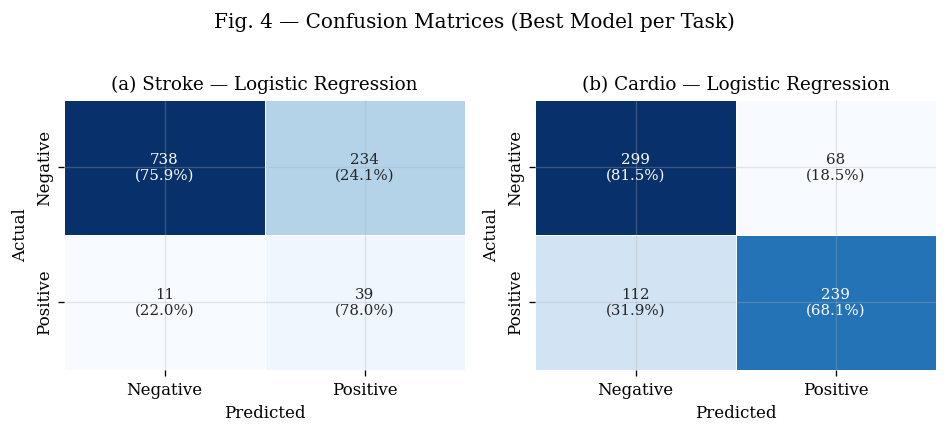

Saved: figures/fig4_confusion_matrices.png


In [11]:
best_s = max(stroke_res, key=lambda r: r['auc'])
best_c = max(cardio_res, key=lambda r: r['auc'])

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, res, yte, title in zip(
        axes,
        [best_s,   best_c],
        [yte_s,    yte_c],
        [f"(a) Stroke — {best_s['name']}",
         f"(b) Cardio — {best_c['name']}"]):

    cm     = confusion_matrix(yte, res['yp'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array(
        [[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
          for row_v, row_p in zip(cm, cm_pct)]
    )
    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues',
        linewidths=0.5, cbar=False,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        ax=ax, annot_kws={'size': 9}
    )
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle('Fig. 4 — Confusion Matrices (Best Model per Task)', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig4_confusion_matrices.png')
plt.show()
print('Saved: figures/fig4_confusion_matrices.png')

## 8. Figure 5 — Feature Importance

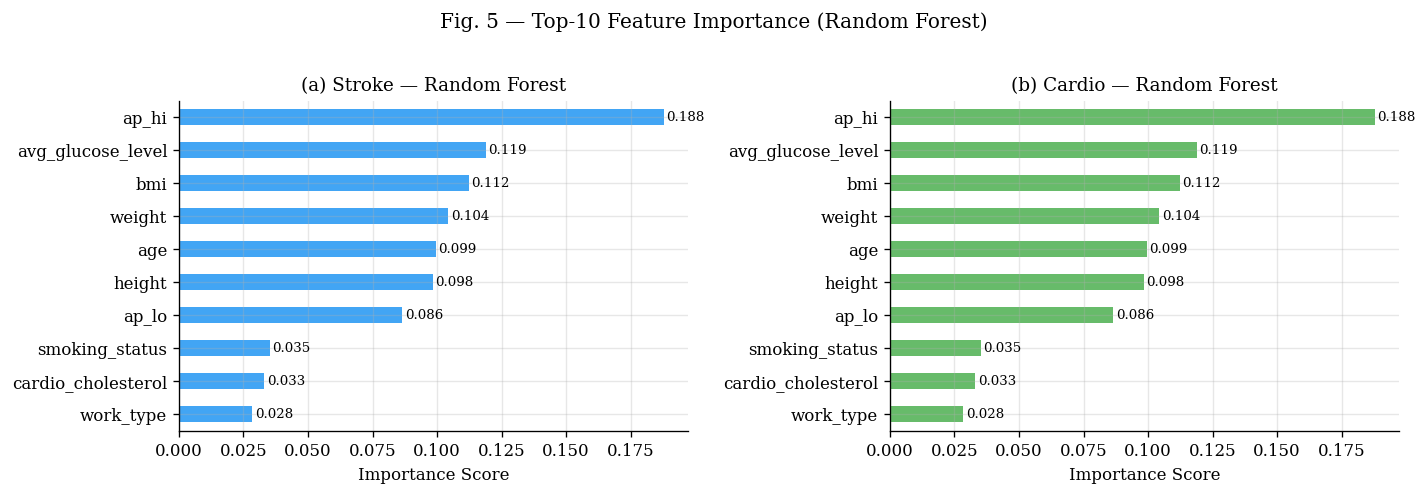

Saved: figures/fig5_feature_importance.png


In [12]:
rf_s = next(r for r in stroke_res if r['name'] == 'Random Forest')
rf_c = next(r for r in cardio_res if r['name'] == 'Random Forest')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, r, title, col in zip(
        axes,
        [rf_s, rf_c],
        ['(a) Stroke — Random Forest', '(b) Cardio — Random Forest'],
        ['#2196F3', '#4CAF50']):

    imp  = pd.Series(r['clf'].feature_importances_, index=FEATURES)
    top  = imp.nlargest(10).sort_values()          # ascending for barh
    top.plot(kind='barh', ax=ax, color=col, alpha=0.85)

    for i, v in enumerate(top):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

    ax.set_xlabel('Importance Score')
    ax.set_title(title)

fig.suptitle('Fig. 5 — Top-10 Feature Importance (Random Forest)', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig5_feature_importance.png')
plt.show()
print('Saved: figures/fig5_feature_importance.png')

## 9. CNN — Brain Scan Classification

In [13]:
BRAIN_DIR  = r'C:\Users\MOHAMED\Desktop\StrokeProject\Brain_Data_Organised'   # غيّر للمسار الصحيح
IMG_SIZE   = (128, 128)
BATCH_SIZE = 16
EPOCHS     = 15

aug_args = dict(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

train_gen = ImageDataGenerator(**aug_args).flow_from_directory(
    BRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=42
)
val_gen = ImageDataGenerator(**aug_args).flow_from_directory(
    BRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42
)

cnn = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print('CNN training done.')

Found 2001 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/15
126/126 [==============================] - 89s 681ms/step - loss: 0.6672 - accuracy: 0.6137 - val_loss: 0.6713 - val_accuracy: 0.6120 - lr: 0.0010
Epoch 2/15
126/126 [==============================] - 76s 596ms/step - loss: 0.6510 - accuracy: 0.6302 - val_loss: 0.6912 - val_accuracy: 0.5560 - lr: 0.0010
Epoch 3/15
126/126 [==============================] - 75s 593ms/step - loss: 0.6368 - accuracy: 0.6357 - val_loss: 0.6907 - val_accuracy: 0.5360 - lr: 0.0010
Epoch 4/15
126/126 [==============================] - 76s 603ms/step - loss: 0.6374 - accuracy: 0.6417 - val_loss: 0.6650 - val_accuracy: 0.6000 - lr: 0.0010
Epoch 5/15
126/126 [==============================] - 77s 614ms/step - loss: 0.6034 - accuracy: 0.6752 - val_loss: 0.7675 - val_accuracy: 0.5840 - lr: 0.0010
Epoch 6/15
126/126 [==============================] - 74s 587ms/step - loss: 0.5827 - accuracy: 0.6912 - val_loss: 0.6906 - val

## 10. Figure 6 — CNN Architecture

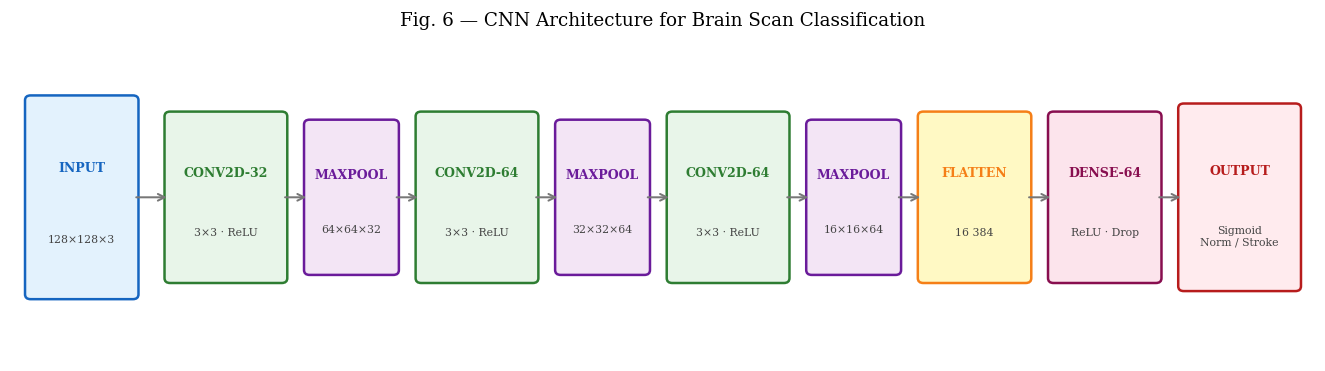

Saved: figures/fig6_cnn_architecture.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

# (x, height, width, facecolor, edgecolor, top_label, bottom_label)
blocks = [
    (0.2,  2.4, 1.1, '#E3F2FD', '#1565C0', 'INPUT',      '128×128×3'),
    (1.7,  2.0, 1.2, '#E8F5E9', '#2E7D32', 'CONV2D-32',  '3×3 · ReLU'),
    (3.2,  1.8, 0.9, '#F3E5F5', '#6A1B9A', 'MAXPOOL',    '64×64×32'),
    (4.4,  2.0, 1.2, '#E8F5E9', '#2E7D32', 'CONV2D-64',  '3×3 · ReLU'),
    (5.9,  1.8, 0.9, '#F3E5F5', '#6A1B9A', 'MAXPOOL',    '32×32×64'),
    (7.1,  2.0, 1.2, '#E8F5E9', '#2E7D32', 'CONV2D-64',  '3×3 · ReLU'),
    (8.6,  1.8, 0.9, '#F3E5F5', '#6A1B9A', 'MAXPOOL',    '16×16×64'),
    (9.8,  2.0, 1.1, '#FFF9C4', '#F57F17', 'FLATTEN',    '16 384'),
    (11.2, 2.0, 1.1, '#FCE4EC', '#880E4F', 'DENSE-64',   'ReLU · Drop'),
    (12.6, 2.2, 1.2, '#FFEBEE', '#B71C1C', 'OUTPUT',     'Sigmoid\nNorm / Stroke'),
]

prev_right = None
for (x, h, w, fc, ec, top, bot) in blocks:
    y0  = (4 - h) / 2
    box = mpatches.FancyBboxPatch(
        (x, y0), w, h,
        boxstyle='round,pad=0.06',
        facecolor=fc, edgecolor=ec, linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x + w/2, y0 + h*0.65, top, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color=ec)
    ax.text(x + w/2, y0 + h*0.28, bot, ha='center', va='center',
            fontsize=6.5, color='#444')
    if prev_right is not None:
        ax.annotate(
            '', xy=(x, 2.0), xytext=(prev_right, 2.0),
            arrowprops=dict(arrowstyle='->', color='#777', lw=1.2)
        )
    prev_right = x + w

ax.set_title('Fig. 6 — CNN Architecture for Brain Scan Classification', pad=6)
plt.savefig('figures/fig6_cnn_architecture.png')
plt.show()
print('Saved: figures/fig6_cnn_architecture.png')

## 11. Figure 7 — CNN Training History & Results

Found 2501 images belonging to 2 classes.
CNN  Acc=0.651  F1=0.576  AUC=0.707
              precision    recall  f1-score   support

      Normal       0.65      0.95      0.77      1551
      Stroke       0.67      0.16      0.26       950

    accuracy                           0.65      2501
   macro avg       0.66      0.56      0.51      2501
weighted avg       0.66      0.65      0.58      2501



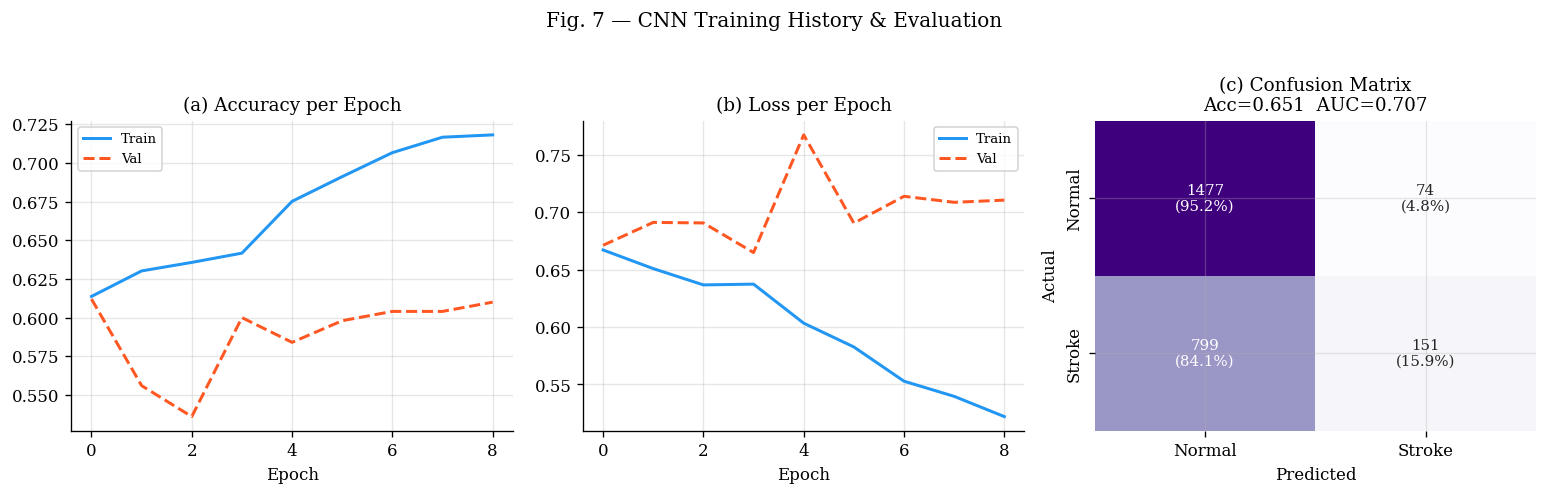

Saved: figures/fig7_cnn_results.png


In [15]:
eval_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    BRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

ypr_cnn = cnn.predict(eval_gen, verbose=0).flatten()
yp_cnn  = (ypr_cnn > 0.5).astype(int)
yt_cnn  = eval_gen.classes
cnames  = list(eval_gen.class_indices.keys())

acc_cnn = accuracy_score(yt_cnn, yp_cnn)
f1_cnn  = f1_score(yt_cnn, yp_cnn, average='weighted')
auc_cnn = roc_auc_score(yt_cnn, ypr_cnn)

print(f'CNN  Acc={acc_cnn:.3f}  F1={f1_cnn:.3f}  AUC={auc_cnn:.3f}')
print(classification_report(yt_cnn, yp_cnn, target_names=cnames))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     color='#2196F3', lw=1.8, label='Train')
axes[0].plot(history.history['val_accuracy'], color='#FF5722', lw=1.8, ls='--', label='Val')
axes[0].set_title('(a) Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)

axes[1].plot(history.history['loss'],     color='#2196F3', lw=1.8, label='Train')
axes[1].plot(history.history['val_loss'], color='#FF5722', lw=1.8, ls='--', label='Val')
axes[1].set_title('(b) Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)

cm     = confusion_matrix(yt_cnn, yp_cnn)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array(
    [[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
      for rv, rp in zip(cm, cm_pct)]
)
sns.heatmap(
    cm, annot=annot, fmt='', cmap='Purples', cbar=False,
    xticklabels=cnames, yticklabels=cnames,
    ax=axes[2], annot_kws={'size': 9}
)
axes[2].set_title(f'(c) Confusion Matrix\nAcc={acc_cnn:.3f}  AUC={auc_cnn:.3f}')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

fig.suptitle('Fig. 7 — CNN Training History & Evaluation', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig7_cnn_results.png')
plt.show()
print('Saved: figures/fig7_cnn_results.png')

## 12. Summary & Save Models

In [16]:
rows = []
for r in stroke_res:
    rows.append({'Task': 'Stroke',     'Model': r['name'],
                 'Accuracy': r['acc'], 'F1': r['f1'], 'ROC-AUC': r['auc']})
for r in cardio_res:
    rows.append({'Task': 'Cardio',     'Model': r['name'],
                 'Accuracy': r['acc'], 'F1': r['f1'], 'ROC-AUC': r['auc']})
rows.append({'Task': 'Brain Scan', 'Model': 'CNN',
             'Accuracy': acc_cnn, 'F1': f1_cnn, 'ROC-AUC': auc_cnn})

summary = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary.to_string(index=False))

summary.to_csv('model_results_summary.csv', index=False)

joblib.dump(best_s['clf'], 'saved_models/stroke_model.pkl')
joblib.dump(sc_s,          'saved_models/stroke_scaler.pkl')
joblib.dump(best_c['clf'], 'saved_models/cardio_model.pkl')
joblib.dump(sc_c,          'saved_models/cardio_scaler.pkl')
cnn.save('saved_models/brain_cnn.h5')

print('\nAll models saved in saved_models/')
print('Figures saved in figures/')
print('\nFigures for IEEE Paper:')
for f in sorted(os.listdir('figures')):
    print(f'  {f}')

      Task               Model  Accuracy     F1  ROC-AUC
    Stroke Logistic Regression    0.7603 0.8275   0.8554
    Stroke       Random Forest    0.9452 0.9259   0.8096
    Stroke             XGBoost    0.9432 0.9278   0.7952
    Cardio Logistic Regression    0.7493 0.7480   0.8007
    Cardio       Random Forest    0.7549 0.7537   0.7938
    Cardio             XGBoost    0.7228 0.7223   0.7680
Brain Scan                 CNN    0.6509 0.5763   0.7075

All models saved in saved_models/
Figures saved in figures/

Figures for IEEE Paper:
  fig1_pipeline.png
  fig2_model_comparison.png
  fig3_roc_curves.png
  fig4_confusion_matrices.png
  fig5_feature_importance.png
  fig6_cnn_architecture.png
  fig7_cnn_results.png
